## Import dependencies

In [14]:
import json
import gzip
import pandas as pd
import requests

## working with downloaded data

In [41]:
with gzip.open("../../data/meta_Electronics.jsonl.gz", "rt") as f:
    first_line = json.loads(f.readline())

In [42]:
first_line

{'main_category': 'All Electronics',
 'title': 'FS-1051 FATSHARK TELEPORTER V3 HEADSET',
 'average_rating': 3.5,
 'rating_number': 6,
 'features': [],
 'description': ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'],
 'price': None,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_US40_.jpg',
   'large': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.

## filter out only recent items (appeared in stock > 2022)

In [45]:
def filter_data_by_date(data: dict) -> bool:
    filter = False
    if int(data["details"]["Date First Available"][-4:]) > 2022:
        filter = True

    return filter

In [44]:
test_dict = {'main_category': 'Gift Cards',
 'title': 'Amazon.com Gift Card in Gift Tag (Various Designs)',
 'average_rating': 4.8,
 'rating_number': 1006,
 'features': ['Gift Card is affixed inside a gift tag',
  'Gift amount may not be printed on Gift Cards',
  'Gift Card has no fees and no expiration date',
  'No returns and no refunds on Gift Cards',
  'Gift Card is redeemable towards millions of items storewide at Amazon.com',
  'Scan and redeem any Gift Card with a mobile or tablet device via the Amazon App',
  'Free One-Day Shipping (where available)',
  'Customized gift message, if chosen at check-out, only appears on packing slip and not on the actual gift card or carrier'],
 'description': ["Amazon.com Gift Cards are the perfect way to give them exactly what they're hoping for - even if you don't know what it is. Amazon.com Gift Cards are redeemable for millions of items across Amazon.com. Item delivered is a single physical Amazon.com Gift Card nested inside or with a free gift accessory."],
 'price': None,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41ZA96xtATL._SX38_SY50_CR,0,0,38,50_.jpg',
   'large': 'https://m.media-amazon.com/images/I/41ZA96xtATL.jpg',
   'variant': 'MAIN',
   'hi_res': 'https://m.media-amazon.com/images/I/71cWJvVGYtL._SL1500_.jpg'},
  {'thumb': 'https://m.media-amazon.com/images/I/41NK1FX6uUL._SX38_SY50_CR,0,0,38,50_.jpg',
   'large': 'https://m.media-amazon.com/images/I/41NK1FX6uUL.jpg',
   'variant': 'PT01',
   'hi_res': 'https://m.media-amazon.com/images/I/71q-qp4b3-L._SL1500_.jpg'},
  {'thumb': 'https://m.media-amazon.com/images/I/41Y45S0GirL._SX38_SY50_CR,0,0,38,50_.jpg',
   'large': 'https://m.media-amazon.com/images/I/41Y45S0GirL.jpg',
   'variant': 'PT02',
   'hi_res': 'https://m.media-amazon.com/images/I/71KutAnl9gL._SL1500_.jpg'},
  {'thumb': 'https://m.media-amazon.com/images/I/417MZ16DhcL._SX38_SY50_CR,0,0,38,50_.jpg',
   'large': 'https://m.media-amazon.com/images/I/417MZ16DhcL.jpg',
   'variant': 'PT03',
   'hi_res': 'https://m.media-amazon.com/images/I/61FMUKaXfJL._SL1175_.jpg'},
  {'thumb': 'https://m.media-amazon.com/images/I/21-tRQuOBZL._SX38_SY50_CR,0,0,38,50_.jpg',
   'large': 'https://m.media-amazon.com/images/I/21-tRQuOBZL.jpg',
   'variant': 'PT12',
   'hi_res': 'https://m.media-amazon.com/images/I/61blLcj3pWL._SL1500_.jpg'}],
 'videos': [],
 'store': 'Amazon',
 'categories': ['Gift Cards', 'Gift Card Recipients', 'For Him'],
 'details': {'Package Dimensions': '5 x 3 x 0.1 inches; 0.63 Ounces',
  'Item model number': 'Fixed',
  'Date First Available': 'August 29, 2017',
  'Manufacturer': 'Amazon'},
 'parent_asin': 'B06ZXTKYHN',
 'bought_together': None}

In [20]:
filter_data_by_date(test_dict)

False

In [46]:
def process_electronics_data():
    input_path = "../../data/meta_Electronics.jsonl.gz"
    matched_path = "../../data/2022-2023.jsonl"
    no_date_path = "../../data/no_date.jsonl"

    processed = 0
    with gzip.open(input_path, "rt") as infile, \
         open(matched_path, "w") as matched_file, \
         open(no_date_path, "w") as no_date_file:
        for line in infile:
            try:
                record = json.loads(line)
                if filter_data_by_date(record):
                    matched_file.write(line)
            except Exception:
                no_date_file.write(line)

            processed += 1
            if processed % 10_000 == 0:
                print(f"Processed {processed} records")

    print(f"Finished processing {processed} records")


process_electronics_data()

Processed 10000 records
Processed 20000 records
Processed 30000 records
Processed 40000 records
Processed 50000 records
Processed 60000 records
Processed 70000 records
Processed 80000 records
Processed 90000 records
Processed 100000 records
Processed 110000 records
Processed 120000 records
Processed 130000 records
Processed 140000 records
Processed 150000 records
Processed 160000 records
Processed 170000 records
Processed 180000 records
Processed 190000 records
Processed 200000 records
Processed 210000 records
Processed 220000 records
Processed 230000 records
Processed 240000 records
Processed 250000 records
Processed 260000 records
Processed 270000 records
Processed 280000 records
Processed 290000 records
Processed 300000 records
Processed 310000 records
Processed 320000 records
Processed 330000 records
Processed 340000 records
Processed 350000 records
Processed 360000 records
Processed 370000 records
Processed 380000 records
Processed 390000 records
Processed 400000 records
Processed

## Explore distribution catgory

In [47]:
df = pd.read_json("../../data/2022-2023.jsonl", lines=True)

In [48]:
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Computers,"Gateway 15.6"" FHD Ultra Slim Budget Notebook, ...",4.1,15,"[【Processor】4 Core, 4 Threads, 4MB Cache, up t...","[Processor:, Intel® Pentium® Silver N5030 Proc...",189.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Watch before you order ', 'url': '...",Gateway,"[Electronics, Computers & Accessories, Compute...",{'Standing screen display size': '15.6 Inches'...,B0BYBG1PPD,NaN
1,Cell Phones & Accessories,May Chen Compatible with MacBook Pro 16 inch C...,4.5,649,[【 COMPATIBLE WITH 】 Designed to Fits Perfectl...,[May Chen High Quality Plastic Hard Shell Case...,26.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'MOSISO Plastic Hard Shell Compati...,May Chen,"[Electronics, Computers & Accessories, Laptop ...","{'Standing screen display size': '16 Inches', ...",B0822SL7JX,NaN
2,All Electronics,USB Bluetooth 1.7 for pc V1.6 EDR Support Wind...,4.0,2,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],XDO,"[Electronics, Computers & Accessories, Network...",{'Product Dimensions': '0.71 x 0.98 x 0.31 inc...,B0BWMR369M,NaN
3,All Electronics,ACAGET USB Type C Headphones for Samsung Galax...,4.0,20,[【Android USB C Headphones】ACAGET Type C earph...,[],14.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'ACAGET USB C Heaadphones Magnetic ...,ACAGET,"[Electronics, Headphones, Earbuds & Accessorie...",{'Package Dimensions': '5.16 x 4.72 x 1.26 inc...,B0C48TKVX7,NaN
4,Cell Phones & Accessories,"MoKo 13-14 Inch Puffy Laptop Sleeve, Cute Lapt...",4.7,19,[Universal Sleeve- The laptop sleeve bag fits ...,[],26.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Tote Bag Organizers #womenstyle', ...",MoKo,"[Electronics, Computers & Accessories, Laptop ...",{'Product Dimensions': '13.39 x 10.24 x 0.98 i...,B0C3LCW7PX,NaN


<Axes: xlabel='main_category'>

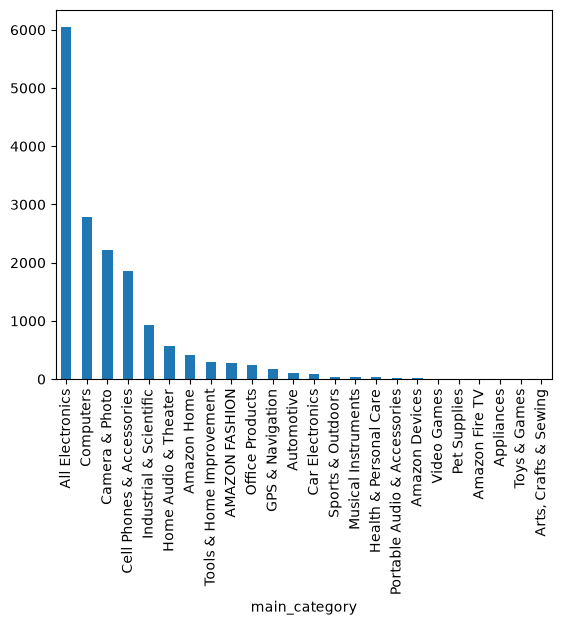

In [49]:
df["main_category"].value_counts().plot(kind="bar")

In [50]:
df_ratings_100 = df[df["rating_number"] >= 100]

In [51]:
len(df)

20406

In [52]:
len(df_ratings_100)

3156

<Axes: xlabel='main_category'>

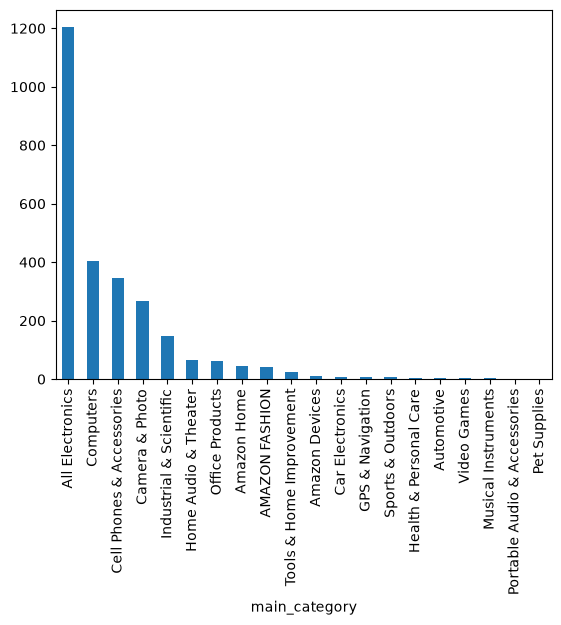

In [53]:
df_ratings_100["main_category"].value_counts().plot(kind="bar")

## explore distribution ratings

<Axes: ylabel='Frequency'>

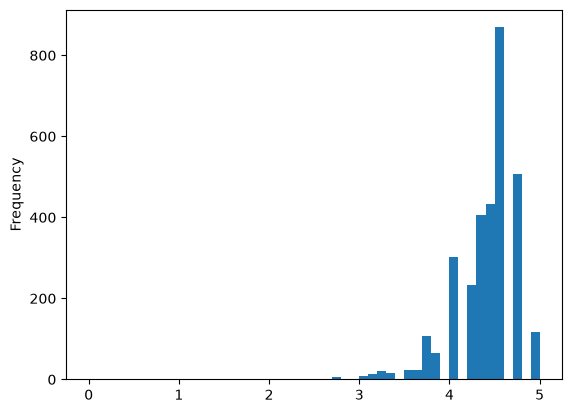

In [54]:
df_ratings_100["average_rating"].plot(kind="hist", bins=50, range=(0,5))

### sample 6

In [55]:
df_sample_1000 = df_ratings_100.sample(n=1000, random_state=42)

In [56]:
len(df_sample_1000)

1000

<Axes: ylabel='Frequency'>

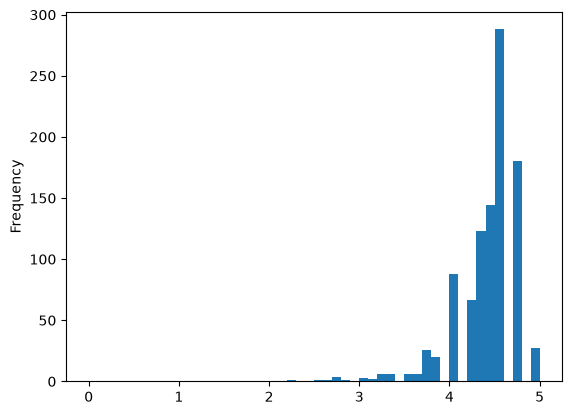

In [57]:
df_sample_1000["average_rating"].plot(kind="hist", bins=50, range=(0,5))

<Axes: ylabel='Frequency'>

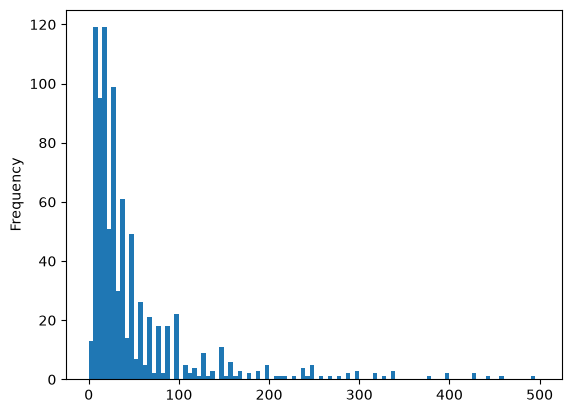

In [58]:
df_sample_1000["price"].plot(kind="hist", bins=100, range=(0,500))

<Axes: xlabel='main_category'>

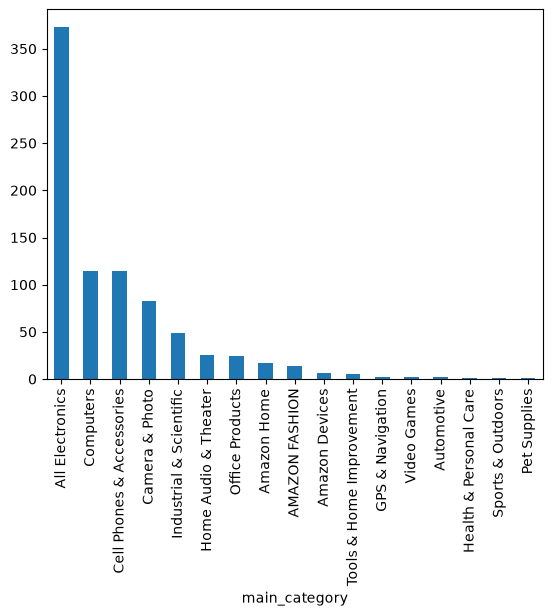

In [60]:
df_sample_1000["main_category"].value_counts().plot(kind="bar")

In [61]:
df_ratings_100.to_json("../../data/meta_electronics_2022_2023_with_category_ratings_100.jsonl", orient='records', lines=True)
df_sample_1000.to_json("../../data/meta_electronics_2022_2023_with_category_ratings_100_samples_1000.jsonl", orient='records', lines=True)

### Extract ratings that match sample data

In [64]:
df_ratings_100 = pd.read_json("../../data/meta_electronics_2022_2023_with_category_ratings_100.jsonl", lines=True)
df_sample_1000 = pd.read_json("../../data/meta_electronics_2022_2023_with_category_ratings_100_samples_1000.jsonl", lines=True)

In [67]:
with gzip.open("../../data/Electronics.jsonl.1.gz", "r") as fp:
    with open("../../data/Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl", 'a') as fp_out:
        id_list = set(df_sample_1000['parent_asin'].values)
        i =0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write('\n')
                fp_out.flush()
            i += 1
            if i % 100000 == 0:
                print(f"processed {i} lines")

processed 100000 lines
processed 200000 lines
processed 300000 lines
processed 400000 lines
processed 500000 lines
processed 600000 lines
processed 700000 lines
processed 800000 lines
processed 900000 lines
processed 1000000 lines
processed 1100000 lines
processed 1200000 lines
processed 1300000 lines
processed 1400000 lines
processed 1500000 lines
processed 1600000 lines
processed 1700000 lines
processed 1800000 lines
processed 1900000 lines
processed 2000000 lines
processed 2100000 lines
processed 2200000 lines
processed 2300000 lines
processed 2400000 lines
processed 2500000 lines
processed 2600000 lines
processed 2700000 lines
processed 2800000 lines
processed 2900000 lines
processed 3000000 lines
processed 3100000 lines
processed 3200000 lines
processed 3300000 lines
processed 3400000 lines
processed 3500000 lines
processed 3600000 lines
processed 3700000 lines
processed 3800000 lines
processed 3900000 lines
processed 4000000 lines
processed 4100000 lines
processed 4200000 lines
p